# 047 视觉Transformer与混合结构

正式先修043与053，编号不是学习顺序。此Notebook真实重做18次固定训练与全部轨迹；CPU float64，无预训练/下载/API。显存未测，CPU保存张量口径另列。

In [1]:
from pathlib import Path
import os,sys,json,hashlib,gzip,tempfile
ROOT=next((p.resolve() for p in [Path.cwd(),Path.cwd()/'units'/'047'] if (p/'experiment.py').is_file() and (p/'data/images.json').is_file()),None)
if ROOT is None:raise RuntimeError('请从047目录或课程根启动')
os.environ.setdefault('MPLCONFIGDIR',str(ROOT/'../../tmp/047-nb-mpl'))
os.environ.setdefault('XDG_CACHE_HOME',str(ROOT/'../../tmp/047-nb-cache'))
sys.path.insert(0,str(ROOT))
expected={'experiment.py': '5706e66e5bbf3a3e77c680782c6e6636053425137cd26fd3f44b531aa9c378ca', 'test_experiment.py': 'b11580af993e3966939ba754585a50c6a25d232a10f44a4ce09344fa1428fe6c', 'generate_data.py': 'e8b3e29ec3ed2b5f3790086c794d1bf717f674be4b262b53205e69f923fe7a51', 'make_figures.py': '9d9b9b4f64fbf3cbf117992fc9d2c50238df537669f77bab30e8b8cce20e81fe', 'data/images.json': '6e497b2fbe1ec3aa1570d757e59a215a0d4ca7ccd82d040afa3dda22ffa6b8db', 'data/data_manifest.json': '07346e4423c66165b506fba649cbc625c06edccba7857fafe0157a48d6c07583', 'outputs/results.json': '0b8afd3332276e9b7b86a3ebcd16198b8e129e86a5b3566b74d3f72a7037c35a', 'outputs/training_traces.json.gz': '11bddddae21352df5a6090772cf2b9dcdc40ad33a5f6c432f223675a842bd898', 'outputs/final_states.json.gz': '9dd9b898ff4fb2b399c962681ad2d6e280cdcabb08438bfeb4de0b5687e2f1c8', 'figures/01_patches.png': 'f72bc9c6a7296d019e9c80e15865d898521462e385aedf0daa1840d6f518c9f0', 'figures/02_connectivity.png': 'c5237453c76f9dd371cd4963d89d143307aa5b797559845f3fe76c5e08a5a88d', 'figures/03_block.png': '8fa835bddbcdba4d94e84ed71962bb319750a84bdb53a50a3becd768c0992668', 'figures/04_hand_attention.png': '44f762ed41b1130bdfd22697dc34f1048d4bfae7162c074fea921f766bff0f73', 'figures/05_softmax_backward.png': '3561f884bf036a5bf90ee5502a8d7359b61e16687f05137851181509c37090f8', 'figures/06_hand_gradients.png': '82d0eda605c7610c898a0d7489b379b8ccf2d0daeb101aa84b4bde95e6d813d4', 'figures/07_updates_positions.png': '791d1beb2edad2598af431d3b6785f2fbcfb3cbd5b77b0b23f165d3e307154de', 'figures/08_data_sensitivity.png': 'd93164c4e41e5def442a666112c02813de66f5f8b2f0cde2ac99d0e61423e6c0', 'figures/09_all_traces.png': '9f882d64b28973f19c4b38ed1b7001945ff2c887b9d4d8e9af20537631a1350b', 'figures/10_resource.png': '194c5d4ce1c094ddc79a09493efb8ec271c8ce61e4eb1a8f3ef13c19c3c3b8ae', 'figures/11_margins.png': 'fe3b4197b8694abe629adbbc3e67456c5148f9ba6bbe921f1fd5d46f1cd6fcc3'}
for name,digest in expected.items():
    if hashlib.sha256((ROOT/name).read_bytes()).hexdigest()!=digest:raise ValueError('版本不一致：'+name)
import numpy as np,torch
import experiment
print('runtime:',sys.version.split()[0],np.__version__,torch.__version__,'checked files:',len(expected))
from IPython.display import Image,display
from io import BytesIO
import matplotlib.pyplot as plt
def show(fig):
    b=BytesIO();fig.savefig(b,format='png',dpi=130,bbox_inches='tight');display(Image(data=b.getvalue()));plt.close(fig)

runtime: 3.12.14 2.3.5 2.7.1+cpu checked files: 20


## 1 独立切片与patch往返
同一个shape可以隐藏错误空间布局；逐窗切片提供不同实现参照。

shape: (1, 6, 12) first patch: [ 0.  1.  6.  7. 24. 25. 30. 31. 48. 49. 54. 55.]


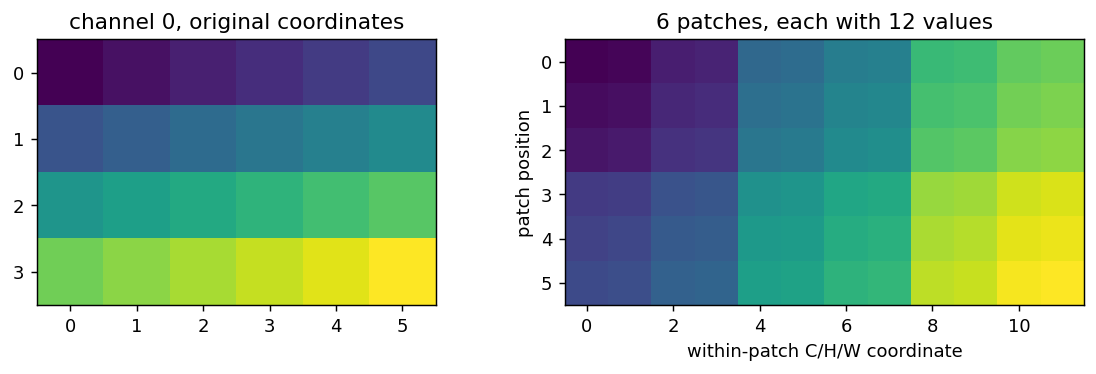

In [2]:
x=np.arange(3*4*6.).reshape(1,3,4,6)
p=experiment.patchify(x,2)
manual=np.stack([x[:,:,r:r+2,c:c+2].reshape(1,-1) for r in range(0,4,2) for c in range(0,6,2)],axis=1)
np.testing.assert_array_equal(p,manual);np.testing.assert_array_equal(experiment.unpatchify(p,2,x.shape),x)
print('shape:',p.shape,'first patch:',p[0,0])
fig,axes=plt.subplots(1,2,figsize=(9,3))
axes[0].imshow(x[0,0],cmap='viridis');axes[0].set_title('channel 0, original coordinates')
axes[1].imshow(p[0],cmap='viridis',aspect='auto');axes[1].set(title='6 patches, each with 12 values',xlabel='within-patch C/H/W coordinate',ylabel='patch position')
fig.tight_layout();show(fig)

## 2 九参数注意力链与下一前向
该D=1子模型没有LN/FFN/残差；完整D=8模型稍后真实训练。

step 0 loss 0.14334981724129228 predictions [0.2539049789307539, 0.12938890408705953]
theta: [0.5, -0.25, 0.0, 0.25, 0.5, 0.5, 1.0, 1.0, 0.0]
gradient: [-0.161022283837621, -0.11664736737957357, -0.16253280815274543, -0.14937497863442972, -0.002345168680486016, -0.002345168680486016, -0.0863478760520385, -0.08634787605203853, -0.3083530584910933]
step 1 loss 0.12568739416856628 predictions [0.3197095462011074, 0.19988615545945643]
theta: [0.5161022283837621, -0.23833526326204263, 0.016253280815274544, 0.26493749786344295, 0.5002345168680487, 0.5002345168680487, 1.0086347876052038, 1.0086347876052038, 0.030835305849109332]
gradient: [-0.12765454431970685, -0.06428457251667818, -0.1307609567363499, -0.11542688887148672, -0.0019030955025015638, -0.0019030955025015636, -0.08066718779374399, -0.08066718779374399, -0.24020214916971805]
step 2 loss 0.1148390538669321 predictions [0.37153530737713053, 0.25374858737374417]
theta: [0.5288676828157327, -0.2319068060103748, 0.029329376488909535, 0

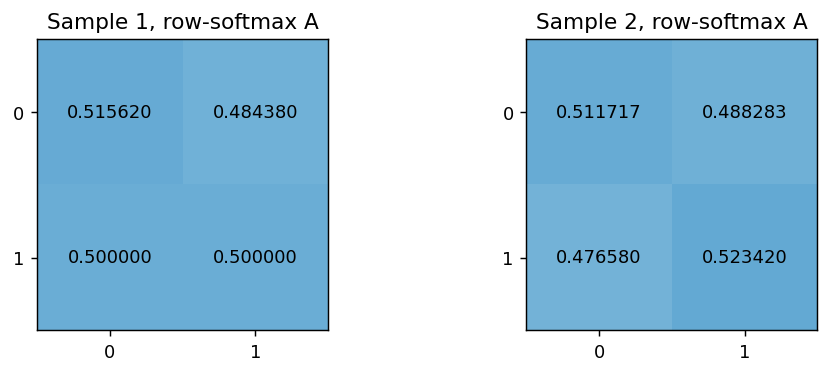

permutation checks: {'permutation': [2, 0, 3, 1], 'no_position_equivariance_max_abs': 4.440892098500626e-16, 'no_position_mean_invariance_max_abs': 4.440892098500626e-16, 'fixed_position_mean_change': 0.7016454636745837, 'joint_permutation_mean_invariance_max_abs': 2.220446049250313e-16}


In [3]:
hand=experiment.hand_ledger()
for state in hand:
    print('step',state['step'],'loss',state['loss'],'predictions',[s['prediction'] for s in state['samples']])
    print('theta:',state['theta']);print('gradient:',state['gradient'])
np.testing.assert_allclose(np.array(hand[0]['theta'])-.1*np.array(hand[0]['gradient']),hand[1]['theta'])
fig,axes=plt.subplots(1,2,figsize=(8,3))
for i,ax in enumerate(axes):
    a=np.array(hand[0]['samples'][i]['attention']);ax.imshow(a,vmin=0,vmax=1,cmap='Blues');ax.set_title(f'Sample {i+1}, row-softmax A');ax.set_xticks([0,1]);ax.set_yticks([0,1])
    for (r,c),v in np.ndenumerate(a):ax.text(c,r,f'{v:.6f}',ha='center',va='center')
fig.tight_layout();show(fig)
print('permutation checks:',experiment.permutation_audit())

## 3 真实重跑18次训练，完整轨迹写临时目录
各规模内图数和更新数相同；未匹配参数/FLOPs，跨规模呈现量改变4倍。后加入的方向规则明确为事后诊断。

In [4]:
with tempfile.TemporaryDirectory() as output:
    fresh=experiment.run(output)
    fresh_trace=json.loads(gzip.decompress((Path(output)/'training_traces.json.gz').read_bytes()))
    fresh_states=json.loads(gzip.decompress((Path(output)/'final_states.json.gz').read_bytes()))
reference=json.loads((ROOT/'outputs/results.json').read_text())
reference_trace=json.loads(gzip.decompress((ROOT/'outputs/training_traces.json.gz').read_bytes()))
def compare(a,b,path='root'):
    if isinstance(a,dict):
        if a.keys()!=b.keys():raise ValueError('key mismatch '+path)
        for k in a:compare(a[k],b[k],path+'.'+k)
    elif isinstance(a,list):
        if len(a)!=len(b):raise ValueError('length mismatch '+path)
        try:
            aa=np.asarray(a,dtype=float);bb=np.asarray(b,dtype=float)
        except (ValueError,TypeError):
            for j,(x,y) in enumerate(zip(a,b)):compare(x,y,path+f'[{j}]')
        else:np.testing.assert_allclose(aa,bb,rtol=1e-8,atol=1e-10,err_msg=path)
    elif isinstance(a,float):np.testing.assert_allclose(a,b,rtol=1e-8,atol=1e-10,err_msg=path)
    elif a!=b:raise ValueError('value mismatch '+path)
for key in ['hand','permutation','runs','summary','orientation_reference']:compare(fresh[key],reference[key],key)
if len(fresh_trace)!=18 or len(fresh_states)!=18:raise ValueError('fit count mismatch')
for ta,tb in zip(fresh_trace,reference_trace):
    if len(ta['states'])!=len(tb['states']) or len(ta['states'])!=201:raise ValueError('trace length mismatch')
    for sa,sb in zip(ta['states'],tb['states']):
        if len(sa['parameters'])!=len(sb['parameters']):raise ValueError('parameter roles differ')
        for pa,pb in zip(sa['parameters'],sb['parameters']):np.testing.assert_allclose(pa,pb,rtol=1e-8,atol=1e-10)
        np.testing.assert_allclose(sa['train_nll'],sb['train_nll'],rtol=1e-8,atol=1e-10)
print('18 fits, 3600 updates and',sum(len(t['states']) for t in fresh_trace),'parameter states recomputed and compared')

18 fits, 3600 updates and 3618 parameter states recomputed and compared


## 4 同时读所有模型、规模与种子
只看准确率或只挑最好种子都会漏掉重要失败。

{
  "32": {
    "cnn": {
      "nll": 0.6872780881552395,
      "accuracy": 0.8880208333333334
    },
    "vit": {
      "nll": 0.7074609147963727,
      "accuracy": 0.6393229166666666
    },
    "hybrid": {
      "nll": 0.47132209539658826,
      "accuracy": 0.71484375
    }
  },
  "128": {
    "cnn": {
      "nll": 0.6880170176228729,
      "accuracy": 0.9049479166666666
    },
    "vit": {
      "nll": 0.7170874561127484,
      "accuracy": 0.52734375
    },
    "hybrid": {
      "nll": 0.4776648594848907,
      "accuracy": 0.9075520833333334
    }
  }
}


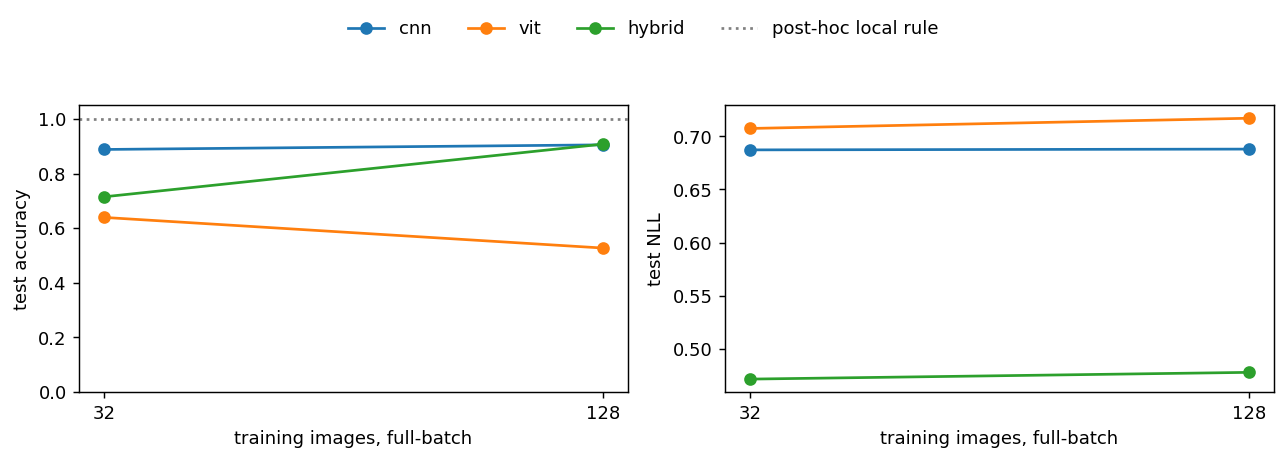

Diagnostic status: post-hoc diagnostic added after viewing first frozen neural runs; not part of original fixed neural comparison


In [5]:
print(json.dumps(fresh['summary'],indent=2))
fig,axes=plt.subplots(1,2,figsize=(10,3.5))
for kind in ['cnn','vit','hybrid']:
    sizes=[32,128]
    axes[0].plot(sizes,[fresh['summary'][str(n)][kind]['accuracy'] for n in sizes],'o-',label=kind)
    axes[1].plot(sizes,[fresh['summary'][str(n)][kind]['nll'] for n in sizes],'o-',label=kind)
axes[0].axhline(fresh['orientation_reference']['splits']['test']['accuracy'],ls=':',color='gray',label='post-hoc local rule')
for ax in axes:ax.set_xticks(sizes);ax.set_xlabel('training images, full-batch')
axes[0].set(ylabel='test accuracy',ylim=(0,1.05));axes[1].set_ylabel('test NLL')
handles,labels=axes[0].get_legend_handles_labels();fig.legend(handles,labels,loc='upper center',bbox_to_anchor=(.5,1.02),ncol=4,frameon=False)
fig.tight_layout(rect=[0,0,1,.84]);show(fig)
print('Diagnostic status:',fresh['orientation_reference']['status'])

## 5 CPU保存张量记录与GPU空值
保存张量体积含输入/参数引用，不能改名为峰值显存。

cnn batch 32 params 682 logical bytes 418248 unique saved storage 286664
vit batch 32 params 802 logical bytes 737032 unique saved storage 605448
hybrid batch 32 params 938 logical bytes 869416 unique saved storage 737832
cnn batch 128 params 682 logical bytes 1657032 unique saved storage 1130696
vit batch 128 params 802 logical bytes 2934280 unique saved storage 2407944
hybrid batch 128 params 938 logical bytes 3459880 unique saved storage 2933544
GPU: {'cuda_available': False, 'peak_vram_bytes': None, 'status': 'not measured; CPU-only runtime'}


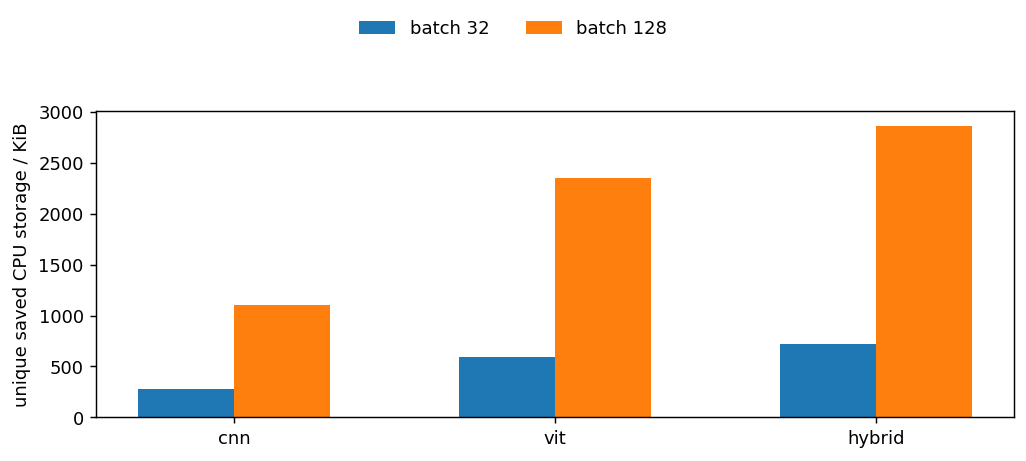

In [6]:
for row in fresh['resource_audit']:
    print(row['kind'],'batch',row['batch'],'params',row['parameter_count'],'logical bytes',row['saved_tensor_logical_bytes'],'unique saved storage',row['unique_saved_storage_bytes'])
print('GPU:',fresh['gpu'])
fig,ax=plt.subplots(figsize=(8,3.5))
kinds=['cnn','vit','hybrid']
for j,batch in enumerate([32,128]):
    ax.bar(np.arange(3)+(j-.5)*.3,[r['unique_saved_storage_bytes']/1024 for r in fresh['resource_audit'] if r['batch']==batch],.3,label=f'batch {batch}')
ax.set_xticks(range(3),kinds);ax.set_ylabel('unique saved CPU storage / KiB')
handles,labels=ax.get_legend_handles_labels();fig.legend(handles,labels,loc='upper center',bbox_to_anchor=(.5,1.02),ncol=2,frameon=False)
fig.tight_layout(rect=[0,0,1,.84]);show(fig)

## 6 独立NumPy模型、802参数差分与最终权重复核
测试是有限输入证据，不是普遍理论保证。

In [7]:
import unittest,test_experiment
checks=unittest.TextTestRunner(verbosity=1).run(unittest.defaultTestLoader.loadTestsFromModule(test_experiment))
if not checks.wasSuccessful():raise RuntimeError('independent tests failed')
print('complete; GPU, browser UI and cross-platform fresh install not validated')

.

.

.

.

.

...

.

.

.

----------------------------------------------------------------------
Ran 9 tests in 1.127s

OK


complete; GPU, browser UI and cross-platform fresh install not validated
